In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('ai_job_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (15000, 19)

Columns:
 ['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']

First 5 rows:


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [4]:
print("=== Dataset Info ===")
df.info()

print("\n=== Basic Statistics ===")
display(df.describe())

print("\n=== Data Types ===")
print(df.dtypes)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date     

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000



=== Data Types ===
job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object


In [5]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates found:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print("\nAfter cleaning — Shape:", df.shape)

=== Missing Values ===
job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

Total missing: 0

=== Duplicate Rows ===
Duplicates found: 0

After cleaning — Shape: (15000, 19)


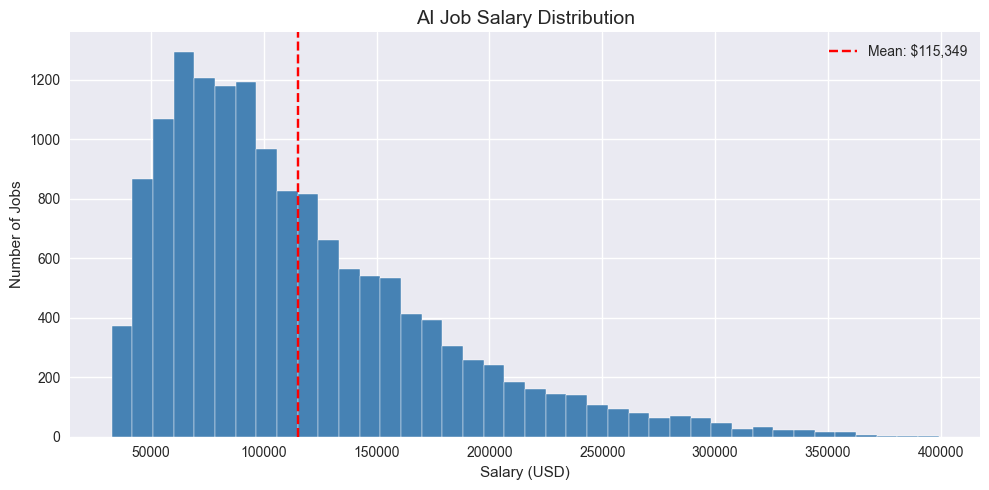

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['salary_usd'], bins=40, color='steelblue', edgecolor='white')
plt.title('AI Job Salary Distribution', fontsize=14)
plt.xlabel('Salary (USD)')
plt.ylabel('Number of Jobs')
plt.axvline(df['salary_usd'].mean(), color='red',
            linestyle='--', label=f"Mean: ${df['salary_usd'].mean():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

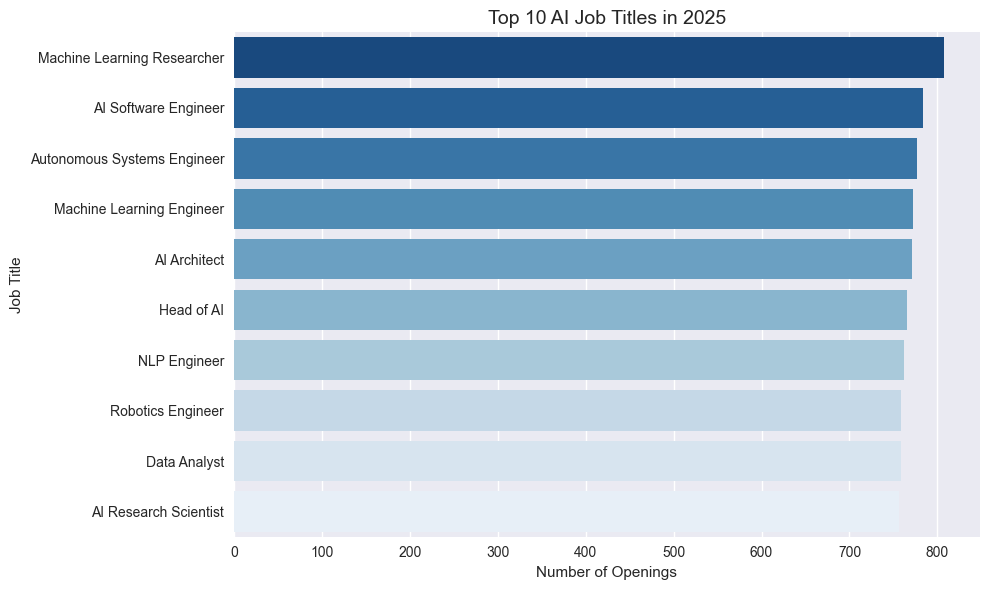

In [7]:
top_jobs = df['job_title'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index,
            hue=top_jobs.index, palette='Blues_r', legend=False)
plt.title('Top 10 AI Job Titles in 2025', fontsize=14)
plt.xlabel('Number of Openings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

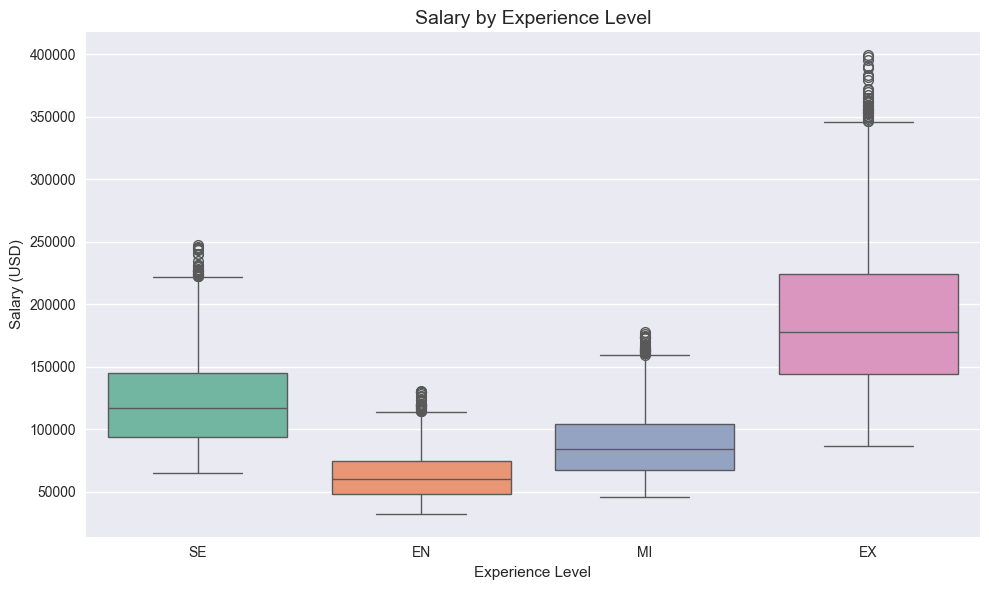

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_usd', hue='experience_level', legend=False, 
            data=df, palette='Set2')
plt.title('Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

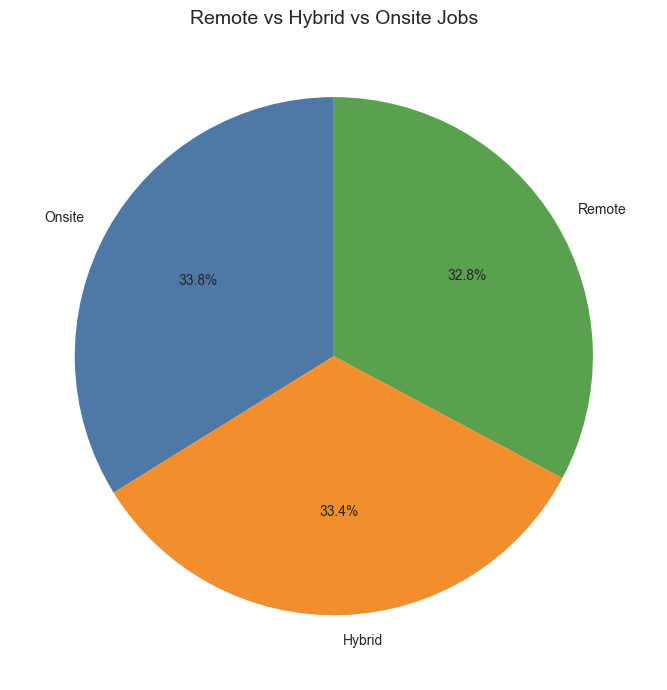

In [9]:
remote_map = {0: 'Onsite', 50: 'Hybrid', 100: 'Remote'}
df['work_type'] = df['remote_ratio'].map(remote_map)
work_counts = df['work_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(work_counts, labels=work_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#4e79a7','#f28e2b','#59a14f'])
plt.title('Remote vs Hybrid vs Onsite Jobs', fontsize=14)
plt.tight_layout()
plt.show()

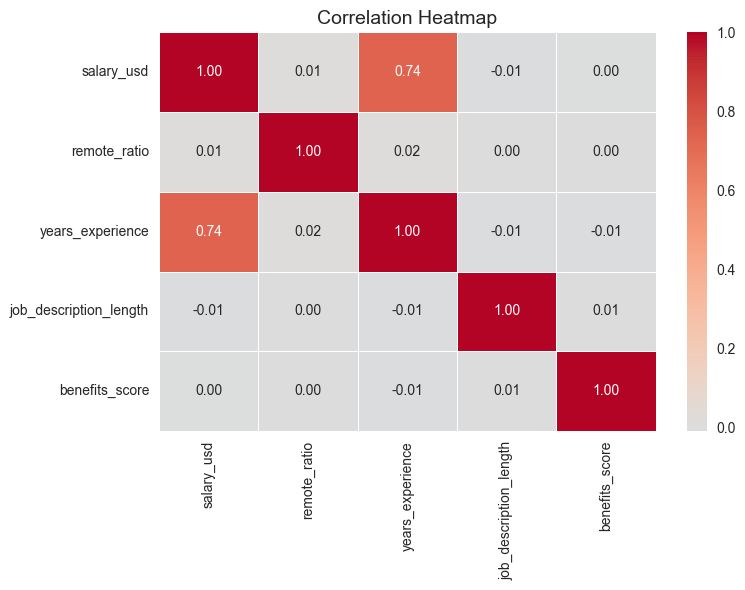

In [10]:
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
df.to_csv('ai_jobs_cleaned.csv', index=False)
print("Cleaned file saved!")
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned file saved!
Final shape: (15000, 20)
Columns: ['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name', 'work_type']


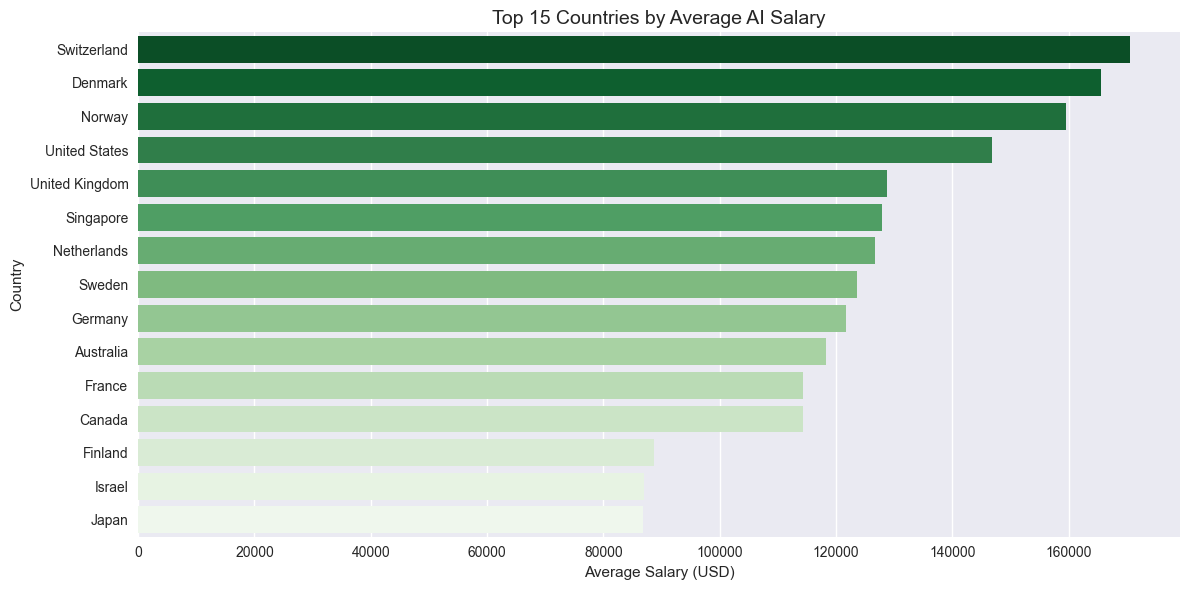

In [12]:
top_countries = df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index,
            hue=top_countries.index, palette='Greens_r', legend=False)
plt.title('Top 15 Countries by Average AI Salary', fontsize=14)
plt.xlabel('Average Salary (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

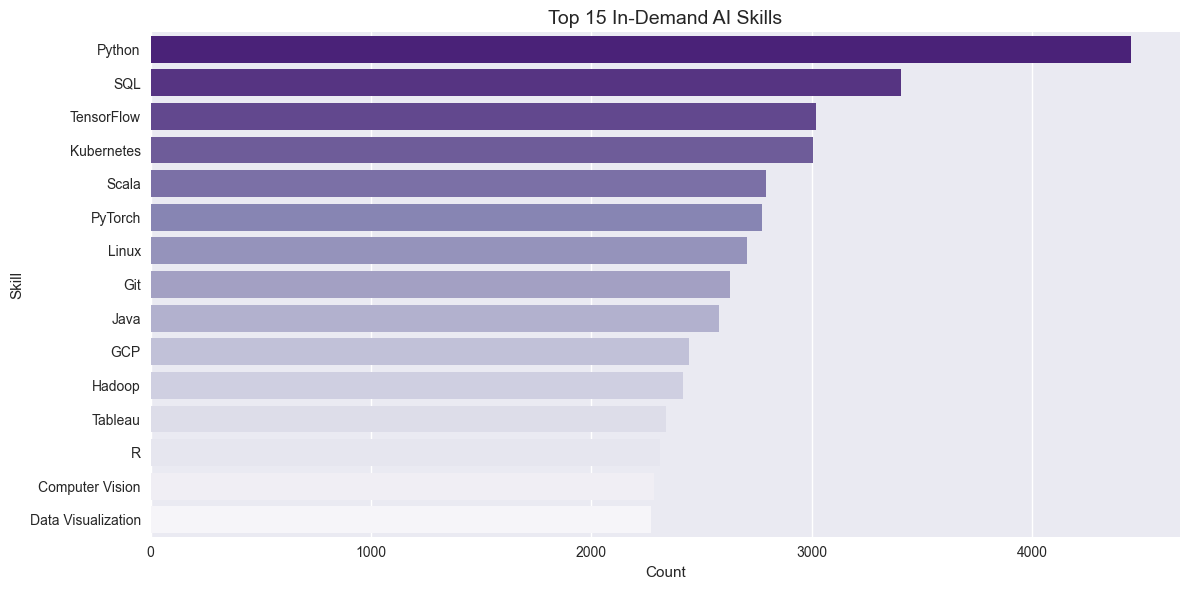

In [13]:
from collections import Counter

all_skills = df['required_skills'].str.split(',').explode().str.strip()
top_skills = pd.Series(Counter(all_skills)).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_skills.values, y=top_skills.index,
            hue=top_skills.index, palette='Purples_r', legend=False)
plt.title('Top 15 In-Demand AI Skills', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

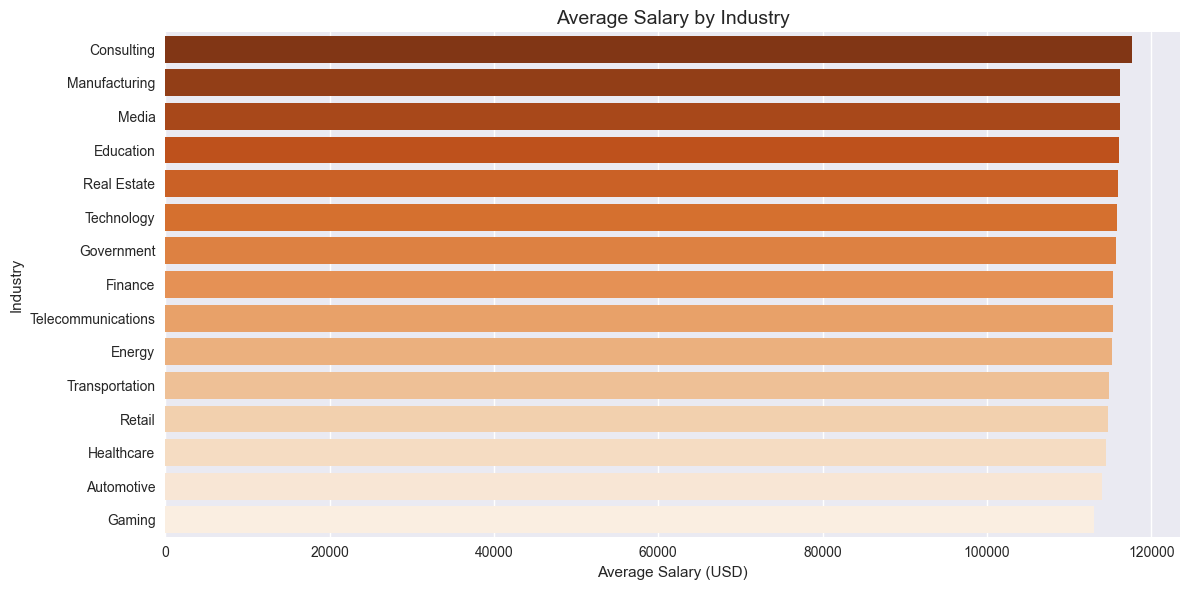

In [14]:
industry_salary = df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=industry_salary.values, y=industry_salary.index,
            hue=industry_salary.index, palette='Oranges_r', legend=False)
plt.title('Average Salary by Industry', fontsize=14)
plt.xlabel('Average Salary (USD)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

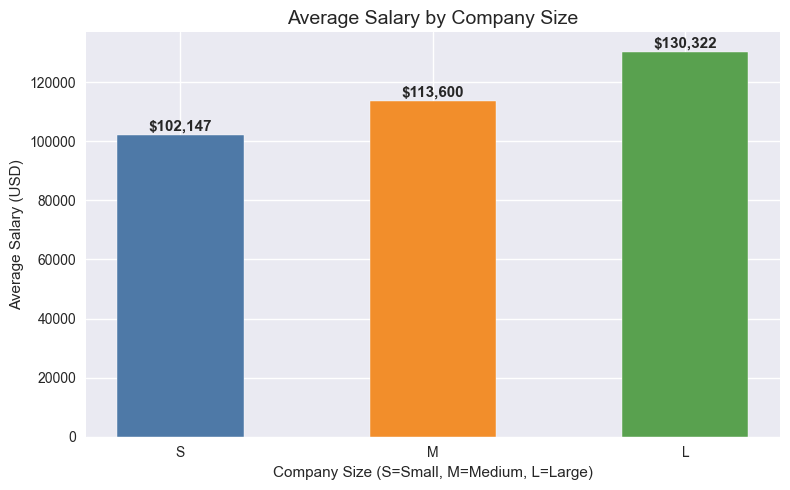

In [17]:
company_salary = df.groupby('company_size')['salary_usd'].mean().reindex(['S', 'M', 'L'])

plt.figure(figsize=(8, 5))
bars = plt.bar(company_salary.index, company_salary.values,
               color=['#4e79a7', '#f28e2b', '#59a14f'], edgecolor='white', width=0.5)

for bar, val in zip(bars, company_salary.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Average Salary by Company Size', fontsize=14)
plt.xlabel('Company Size (S=Small, M=Medium, L=Large)')
plt.ylabel('Average Salary (USD)')
plt.tight_layout()
plt.show()